In [1]:
# ============================================================================
# IMPORTS & SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
import warnings
from google.colab import files
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Suppress warnings
warnings.filterwarnings('ignore')

# Set Global Random Seed
random_seed = 2025

random.seed(random_seed)
np.random.seed(random_seed)


In [2]:
# ============================================================================
# TASK 1: File upload
# ============================================================================

# mount gdrive directory
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

# load dataset
# file: Dataset2Use_Assignment1.xlsx should be uploaded at google drive:Datasets
fileNameFullPath = '/content/drive/MyDrive/Datasets/Dataset2Use_Assignment1.xlsx'
df = pd.read_excel(fileNameFullPath)

Mounted at /content/drive


In [3]:
# ============================================================================
# TASK 3: Check for missing values
# ============================================================================


# Check for NaN values
nan_report = df.isna().sum()

# Calculate the percentage of NaN values per column
nan_percentage_report = (df.isna().mean() * 100).round(2)

# Combine count and percentage reports into a single DataFrame
combined_report = pd.concat(
    [nan_report, nan_percentage_report],
    axis=1,
    keys=['NaN Count', 'NaN Percentage']
)

# Print the combined NaN report
print("Combined NaN Report:")
print(combined_report)

# Check if there are any missing values in the dataset
if combined_report.values.max() == 0:
    print("\nGood news! There are no missing values in the dataset.")
else:
    print("\nWarning: There are missing values in the dataset.")


Combined NaN Report:
                                                NaN Count  NaN Percentage
365* ( Β.Υ / Κοστ.Πωλ )                                 0             0.0
Λειτ.Αποτ/Συν.Ενεργ. (ROA)                              0             0.0
ΧΡΗΜ.ΔΑΠΑΝΕΣ / ΠΩΛΗΣΕΙΣ                                 0             0.0
 ΠΡΑΓΜΑΤΙΚΗ ΡΕΥΣΤΟΤΗΤΑ :  (ΚΕ-ΑΠΟΘΕΜΑΤΑ) / Β.Υ          0             0.0
(ΑΠΑΙΤ.*365) / ΠΩΛ.                                     0             0.0
Συν.Υποχρ/Συν.Ενεργ                                     0             0.0
Διάρκεια Παραμονής Αποθεμάτων                           0             0.0
Λογαριθμος Προσωπικού                                   0             0.0
ΕΝΔΕΙΞΗ ΕΞΑΓΩΓΩΝ                                        0             0.0
ΕΝΔΕΙΞΗ ΕΙΣΑΓΩΓΩΝ                                       0             0.0
ΕΝΔΕΙΞΗ ΑΝΤΙΠΡΟΣΩΠΕΙΩΝ                                  0             0.0
ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)                           0             0.0
ΕΤΟΣ             

In [4]:
# Variable Setup
status_col = "ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)"
year_col = "ΕΤΟΣ"

# First 8 columns = indicators
indicator_cols = df.columns[:8]

df.columns

Index(['365* ( Β.Υ / Κοστ.Πωλ )', 'Λειτ.Αποτ/Συν.Ενεργ. (ROA)',
       'ΧΡΗΜ.ΔΑΠΑΝΕΣ / ΠΩΛΗΣΕΙΣ',
       ' ΠΡΑΓΜΑΤΙΚΗ ΡΕΥΣΤΟΤΗΤΑ :  (ΚΕ-ΑΠΟΘΕΜΑΤΑ) / Β.Υ', '(ΑΠΑΙΤ.*365) / ΠΩΛ.',
       'Συν.Υποχρ/Συν.Ενεργ', 'Διάρκεια Παραμονής Αποθεμάτων',
       'Λογαριθμος Προσωπικού', 'ΕΝΔΕΙΞΗ ΕΞΑΓΩΓΩΝ', 'ΕΝΔΕΙΞΗ ΕΙΣΑΓΩΓΩΝ',
       'ΕΝΔΕΙΞΗ ΑΝΤΙΠΡΟΣΩΠΕΙΩΝ', 'ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)', 'ΕΤΟΣ'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

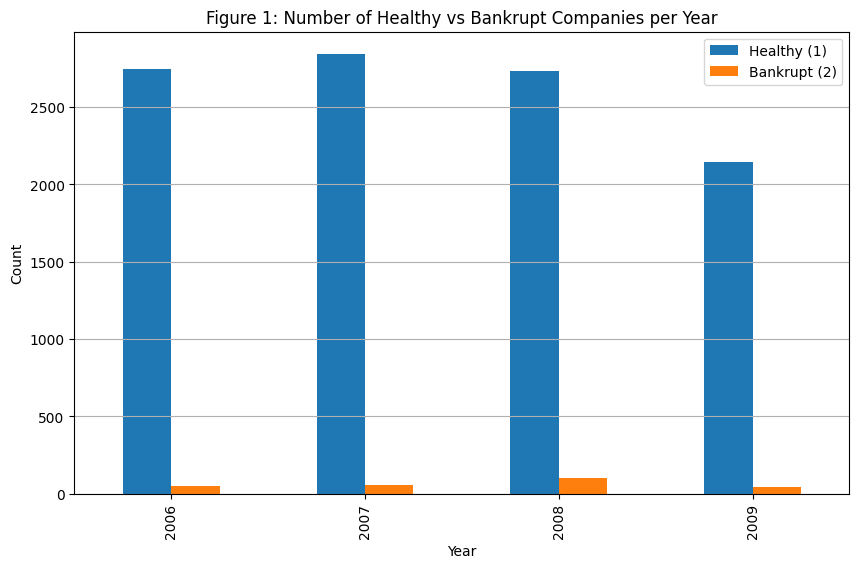

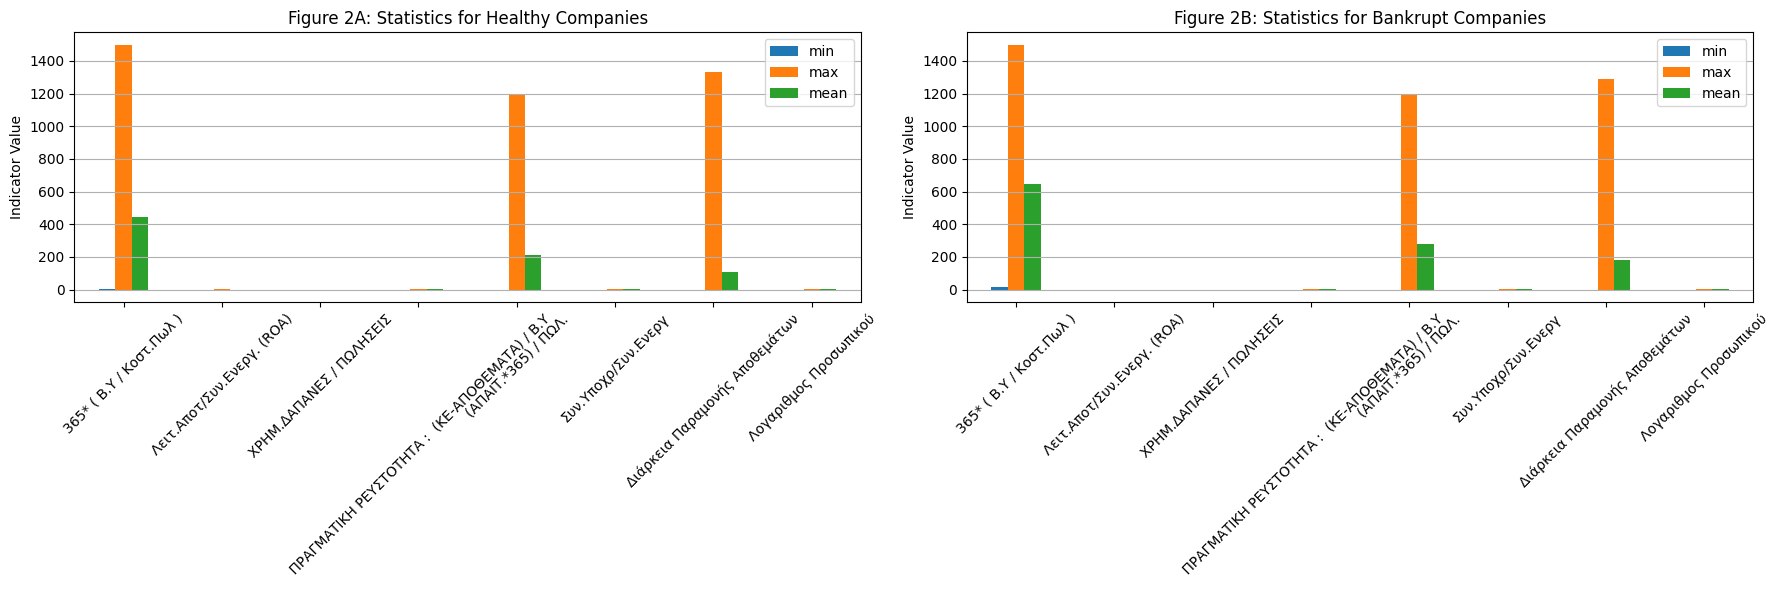

In [5]:
# ============================================================================
# TASK 2: Exploratory Data Analysis - Visualizations
# ============================================================================


# FIGURE 1 (HEALTHY vs BANKRUPT PER YEAR)

plt.figure(figsize=(10,6))

# Count companies by year and financial status
counts = df.groupby([year_col, status_col]).size().unstack().fillna(0)

# Plot the counts as a bar chart
counts.plot(kind='bar', figsize=(10,6))

plt.title("Figure 1: Number of Healthy vs Bankrupt Companies per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(["Healthy (1)", "Bankrupt (2)"])
plt.grid(axis='y')

# Save Figure 1
plt.savefig("figure1_healthy_vs_bankrupt_per_year.png", dpi=300, bbox_inches="tight")

plt.show()


# FIGURE 2 (MIN / MAX / MEAN INDICATOR VALUES)


# Separate the dataset into healthy and bankrupt companies
healthy_df = df[df[status_col] == 1]
bankrupt_df = df[df[status_col] == 2]

# Calculate min, max, and mean values for each indicator
healthy_stats = pd.DataFrame({
    "min": healthy_df[indicator_cols].min(),
    "max": healthy_df[indicator_cols].max(),
    "mean": healthy_df[indicator_cols].mean()
})

bankrupt_stats = pd.DataFrame({
    "min": bankrupt_df[indicator_cols].min(),
    "max": bankrupt_df[indicator_cols].max(),
    "mean": bankrupt_df[indicator_cols].mean()
})

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Healthy companies
healthy_stats.plot.bar(ax=axes[0])
axes[0].set_title("Figure 2A: Statistics for Healthy Companies")
axes[0].set_ylabel("Indicator Value")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Bankrupt companies
bankrupt_stats.plot.bar(ax=axes[1])
axes[1].set_title("Figure 2B: Statistics for Bankrupt Companies")
axes[1].set_ylabel("Indicator Value")
axes[1].grid(axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save subfigures separately
fig.savefig("figure2A_2B.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# ============================================================================
# TASK 4: Data Preparation - Normalization with Min-Max Scaling
# ============================================================================


# Normalize the indicator features to the range [0, 1] using Min-Max scaling.
from sklearn.preprocessing import MinMaxScaler

# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the selected indicator columns
df[indicator_cols] = scaler.fit_transform(df[indicator_cols])

# Confirm that normalization was applied
print("\nMinMax scaling applied successfully!")


inputData = df[indicator_cols]
outputData = df[status_col]




MinMax scaling applied successfully!


Models initialized.
 Starting Training Loop (4 Folds)...



   PROCESSING FOLD 1

--- Fold Set No: 1 ---
6. Initial Train Set | Υγιείς (1): 7851, Χρεοκοπημένες (2): 186
6. Test Set          | Υγιείς (1): 2617, Χρεοκοπημένες (2): 62

ATTENTION: Ratio > 3/1 detected. Applying undersampling for balancing
7. New **Balanced** Train Set | Υγιείς (1): 558, Χρεοκοπημένες (2): 186
 



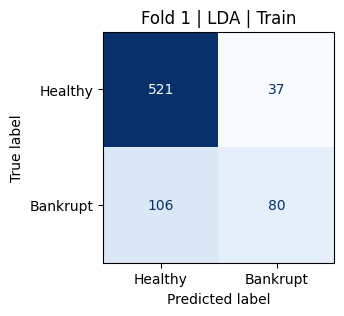

 
Model: LDA (Train) | AUC: 0.84
 


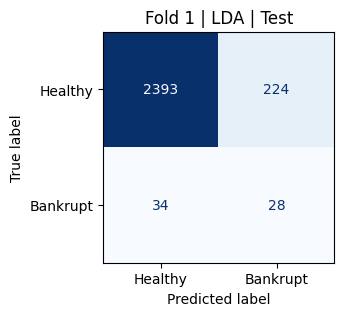

 
Model: LDA (Test) | AUC: 0.85
 


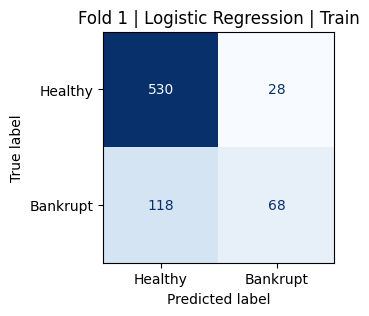

 
Model: Logistic Regression (Train) | AUC: 0.84
 


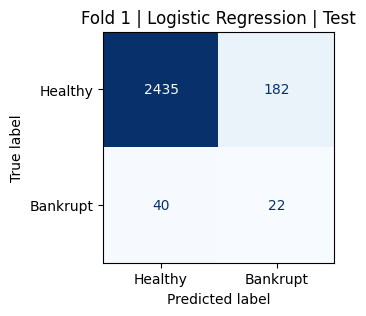

 
Model: Logistic Regression (Test) | AUC: 0.84
 


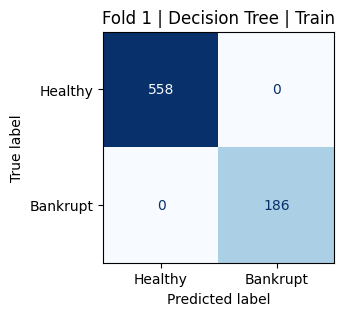

 
Model: Decision Tree (Train) | AUC: 1.00
 


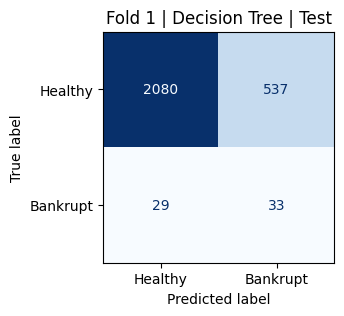

 
Model: Decision Tree (Test) | AUC: 0.66
 


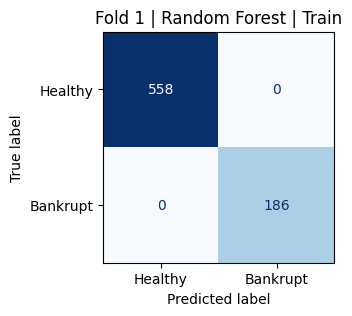

 
Model: Random Forest (Train) | AUC: 1.00
 


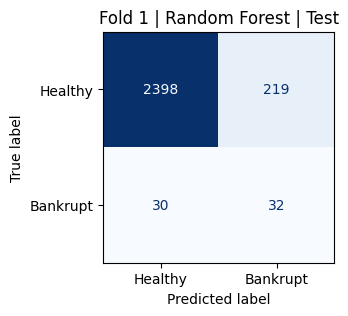

 
Model: Random Forest (Test) | AUC: 0.87
 


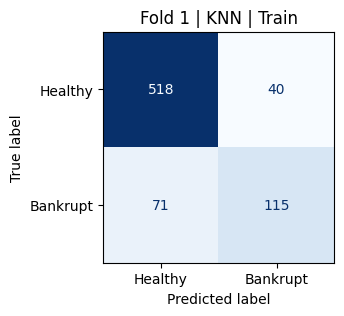

 
Model: KNN (Train) | AUC: 0.91
 


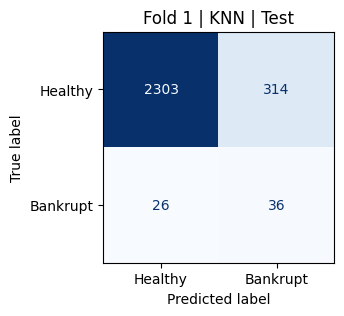

 
Model: KNN (Test) | AUC: 0.82
 


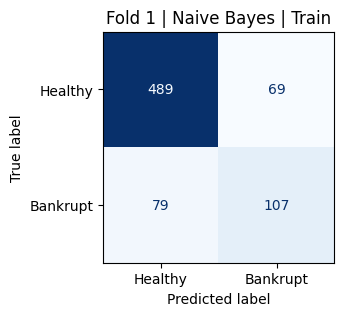

 
Model: Naive Bayes (Train) | AUC: 0.83
 


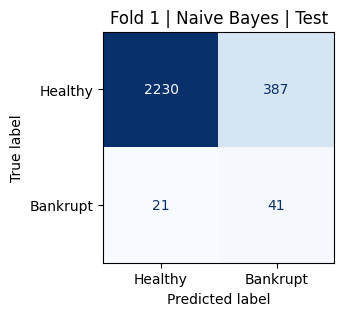

 
Model: Naive Bayes (Test) | AUC: 0.85
 


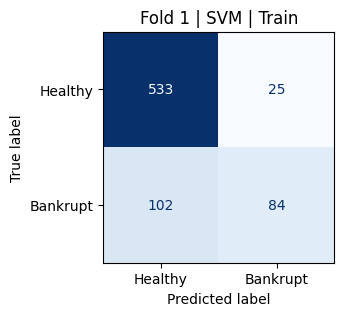

 
Model: SVM (Train) | AUC: 0.88
 


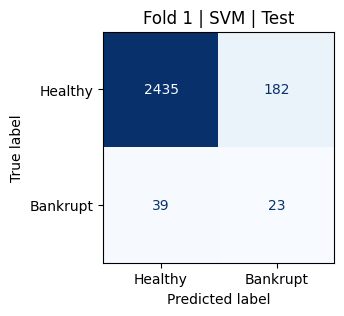

 
Model: SVM (Test) | AUC: 0.85
 


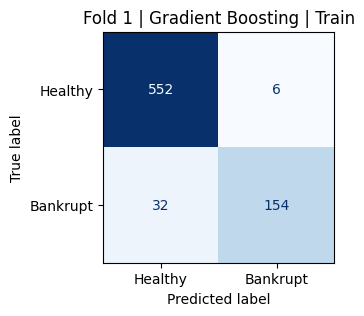

 
Model: Gradient Boosting (Train) | AUC: 0.99
 


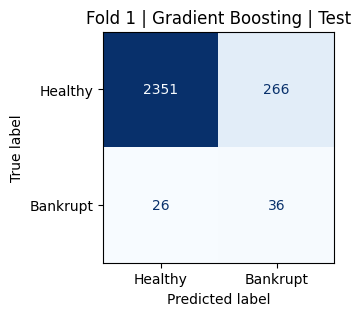

 
Model: Gradient Boosting (Test) | AUC: 0.86
 



   PROCESSING FOLD 2

--- Fold Set No: 2 ---
6. Initial Train Set | Υγιείς (1): 7851, Χρεοκοπημένες (2): 186
6. Test Set          | Υγιείς (1): 2617, Χρεοκοπημένες (2): 62

ATTENTION: Ratio > 3/1 detected. Applying undersampling for balancing
7. New **Balanced** Train Set | Υγιείς (1): 558, Χρεοκοπημένες (2): 186
 



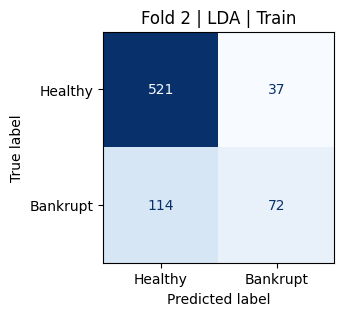

 
Model: LDA (Train) | AUC: 0.84
 


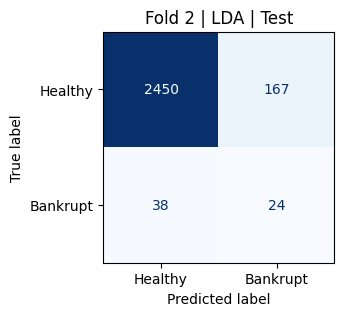

 
Model: LDA (Test) | AUC: 0.84
 


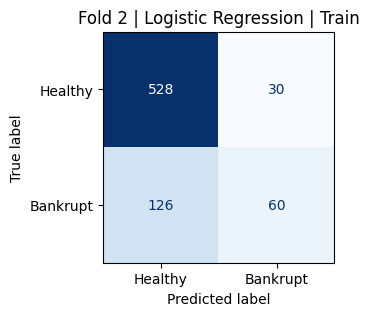

 
Model: Logistic Regression (Train) | AUC: 0.84
 


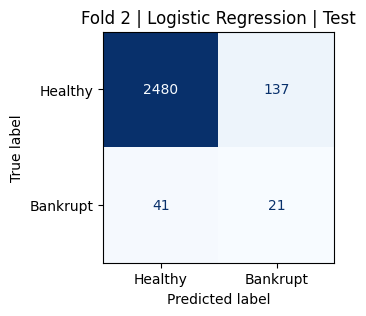

 
Model: Logistic Regression (Test) | AUC: 0.84
 


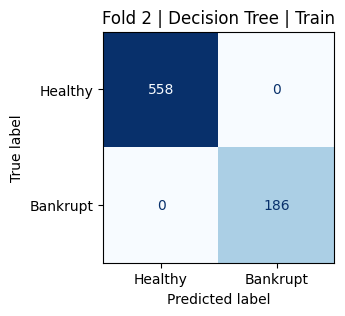

 
Model: Decision Tree (Train) | AUC: 1.00
 


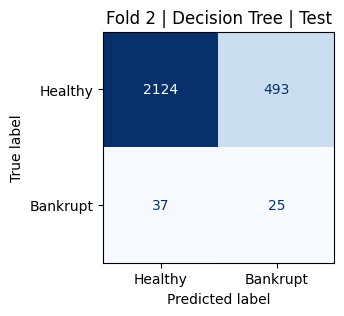

 
Model: Decision Tree (Test) | AUC: 0.61
 


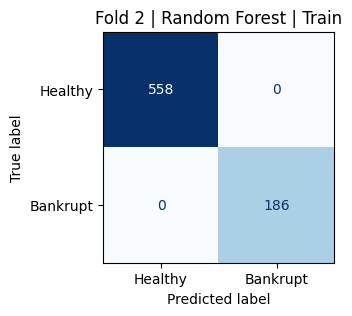

 
Model: Random Forest (Train) | AUC: 1.00
 


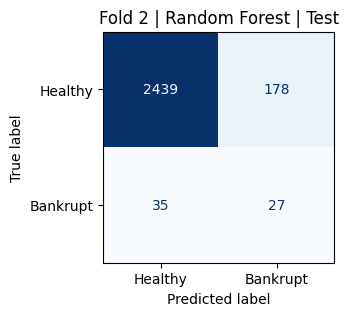

 
Model: Random Forest (Test) | AUC: 0.83
 


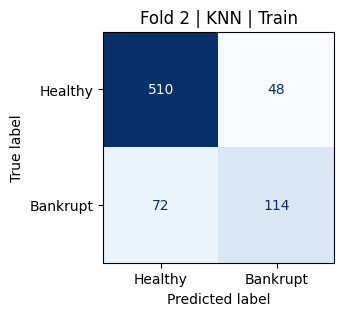

 
Model: KNN (Train) | AUC: 0.90
 


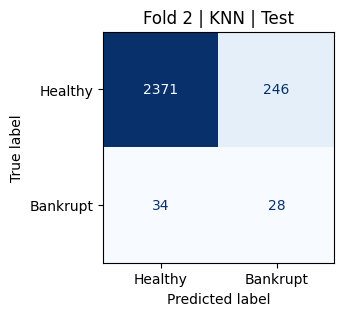

 
Model: KNN (Test) | AUC: 0.81
 


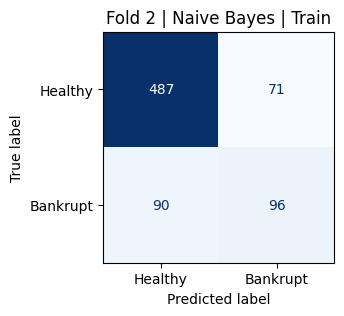

 
Model: Naive Bayes (Train) | AUC: 0.82
 


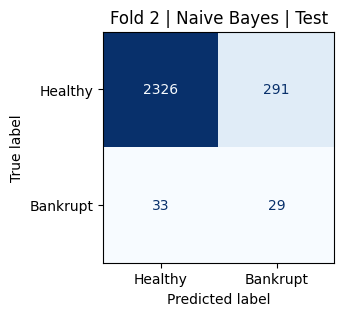

 
Model: Naive Bayes (Test) | AUC: 0.82
 


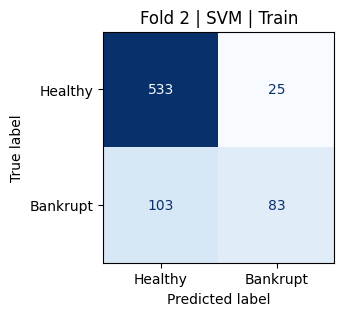

 
Model: SVM (Train) | AUC: 0.88
 


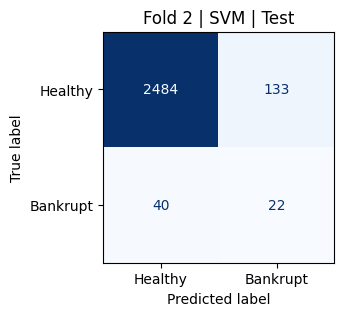

 
Model: SVM (Test) | AUC: 0.84
 


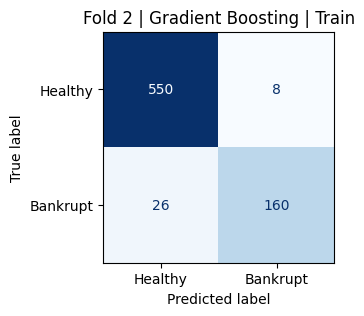

 
Model: Gradient Boosting (Train) | AUC: 0.99
 


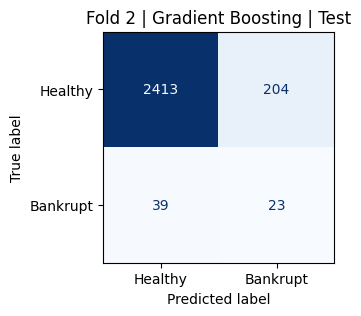

 
Model: Gradient Boosting (Test) | AUC: 0.82
 



   PROCESSING FOLD 3

--- Fold Set No: 3 ---
6. Initial Train Set | Υγιείς (1): 7851, Χρεοκοπημένες (2): 186
6. Test Set          | Υγιείς (1): 2617, Χρεοκοπημένες (2): 62

ATTENTION: Ratio > 3/1 detected. Applying undersampling for balancing
7. New **Balanced** Train Set | Υγιείς (1): 558, Χρεοκοπημένες (2): 186
 



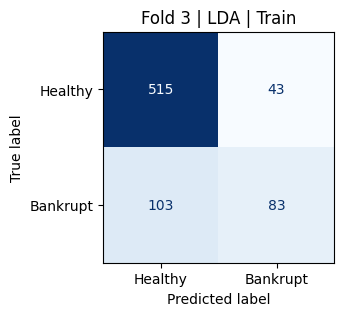

 
Model: LDA (Train) | AUC: 0.86
 


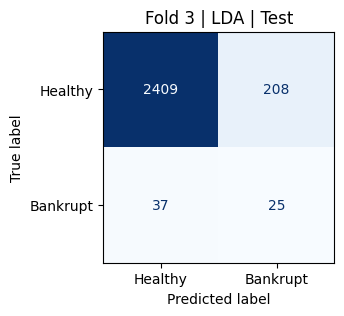

 
Model: LDA (Test) | AUC: 0.79
 


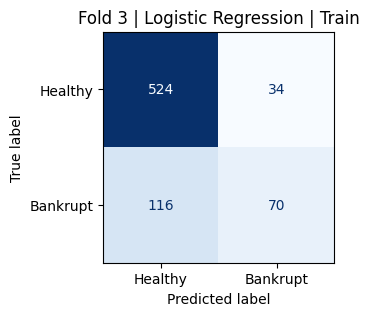

 
Model: Logistic Regression (Train) | AUC: 0.86
 


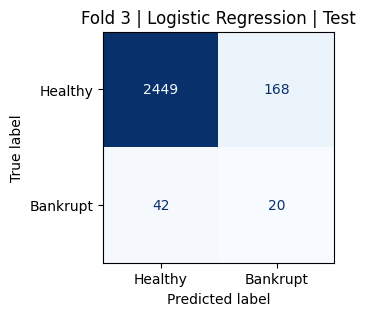

 
Model: Logistic Regression (Test) | AUC: 0.79
 


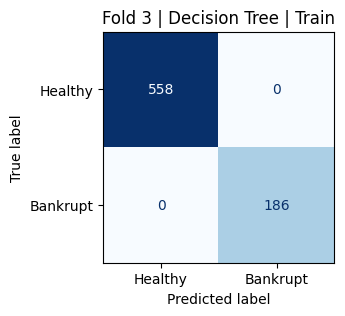

 
Model: Decision Tree (Train) | AUC: 1.00
 


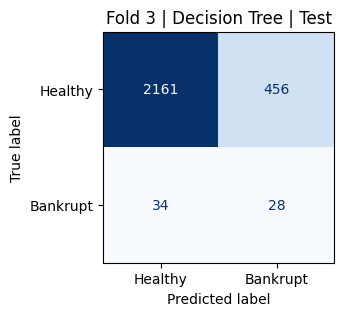

 
Model: Decision Tree (Test) | AUC: 0.64
 


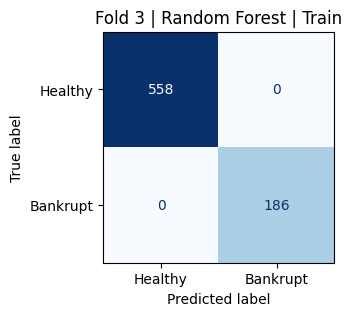

 
Model: Random Forest (Train) | AUC: 1.00
 


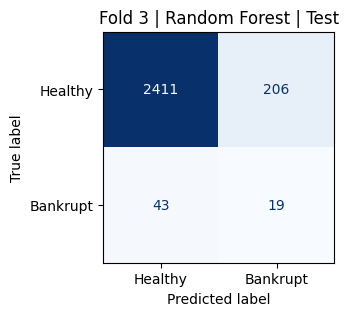

 
Model: Random Forest (Test) | AUC: 0.82
 


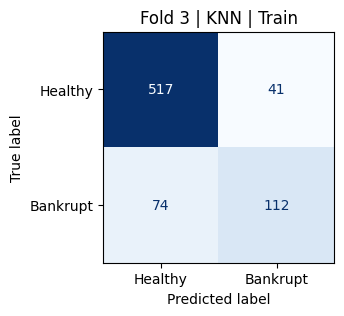

 
Model: KNN (Train) | AUC: 0.92
 


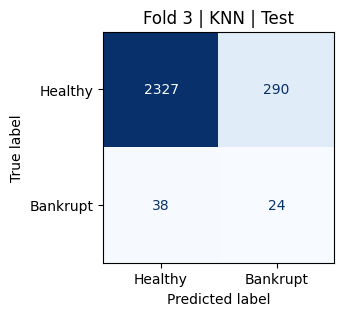

 
Model: KNN (Test) | AUC: 0.78
 


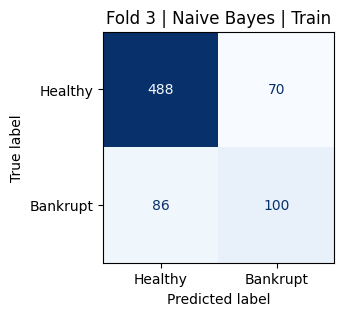

 
Model: Naive Bayes (Train) | AUC: 0.85
 


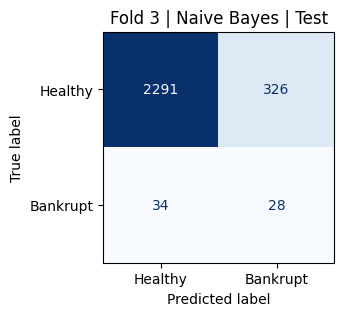

 
Model: Naive Bayes (Test) | AUC: 0.78
 


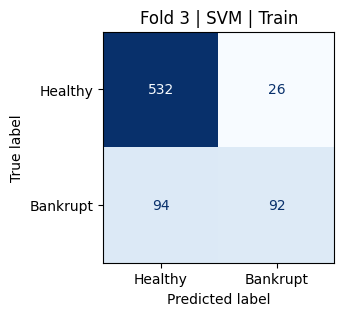

 
Model: SVM (Train) | AUC: 0.89
 


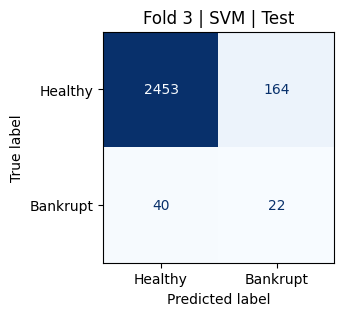

 
Model: SVM (Test) | AUC: 0.80
 


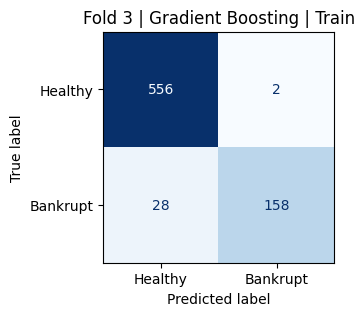

 
Model: Gradient Boosting (Train) | AUC: 0.99
 


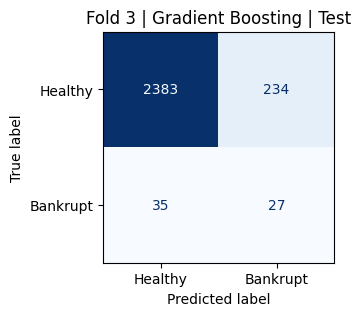

 
Model: Gradient Boosting (Test) | AUC: 0.81
 



   PROCESSING FOLD 4

--- Fold Set No: 4 ---
6. Initial Train Set | Υγιείς (1): 7851, Χρεοκοπημένες (2): 186
6. Test Set          | Υγιείς (1): 2617, Χρεοκοπημένες (2): 62

ATTENTION: Ratio > 3/1 detected. Applying undersampling for balancing
7. New **Balanced** Train Set | Υγιείς (1): 558, Χρεοκοπημένες (2): 186
 



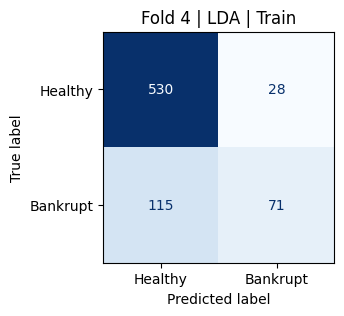

 
Model: LDA (Train) | AUC: 0.85
 


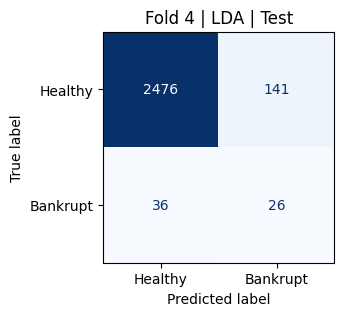

 
Model: LDA (Test) | AUC: 0.85
 


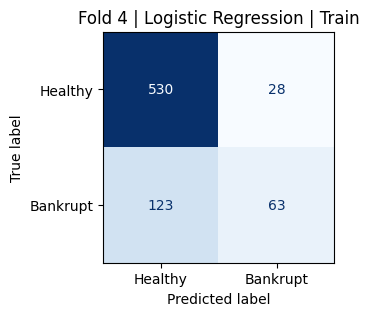

 
Model: Logistic Regression (Train) | AUC: 0.85
 


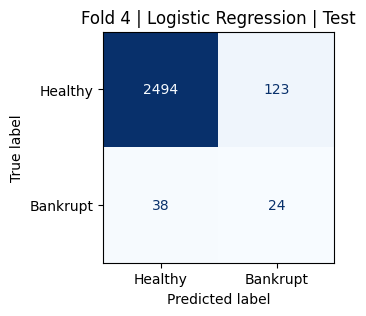

 
Model: Logistic Regression (Test) | AUC: 0.85
 


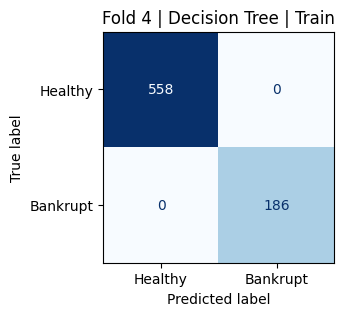

 
Model: Decision Tree (Train) | AUC: 1.00
 


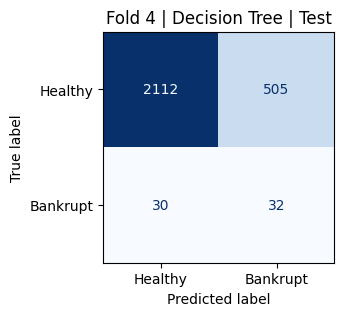

 
Model: Decision Tree (Test) | AUC: 0.66
 


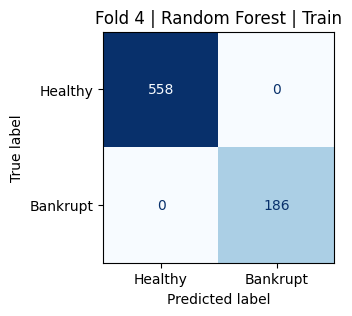

 
Model: Random Forest (Train) | AUC: 1.00
 


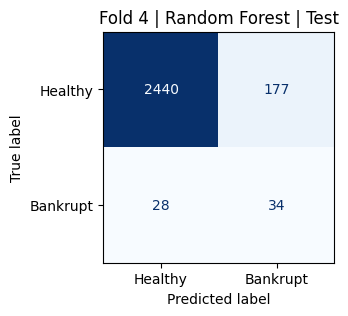

 
Model: Random Forest (Test) | AUC: 0.89
 


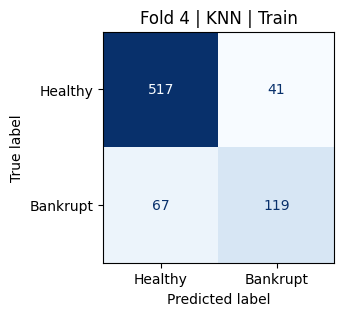

 
Model: KNN (Train) | AUC: 0.92
 


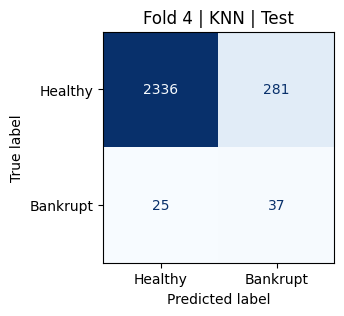

 
Model: KNN (Test) | AUC: 0.83
 


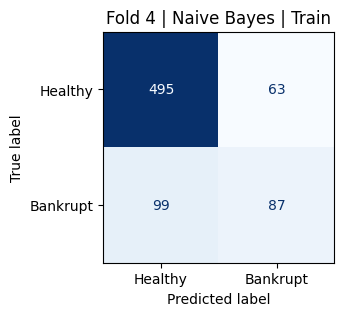

 
Model: Naive Bayes (Train) | AUC: 0.83
 


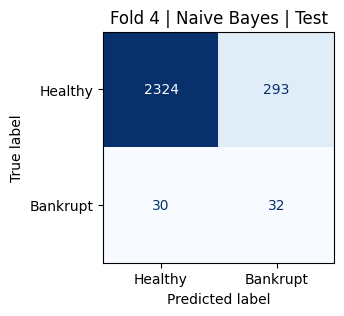

 
Model: Naive Bayes (Test) | AUC: 0.84
 


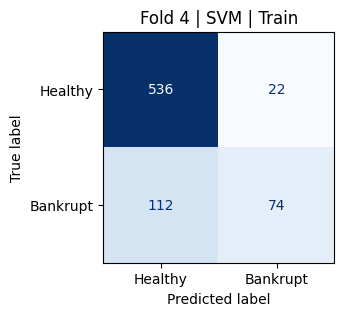

 
Model: SVM (Train) | AUC: 0.89
 


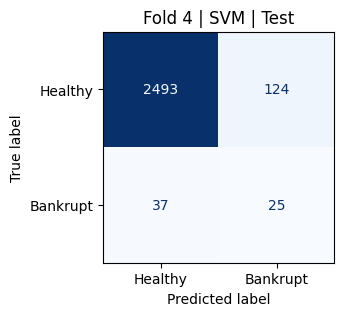

 
Model: SVM (Test) | AUC: 0.85
 


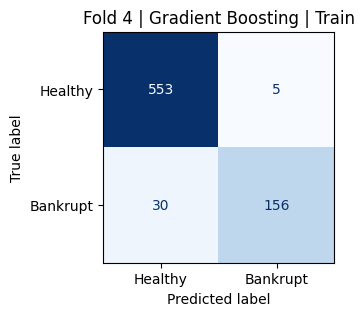

 
Model: Gradient Boosting (Train) | AUC: 0.99
 


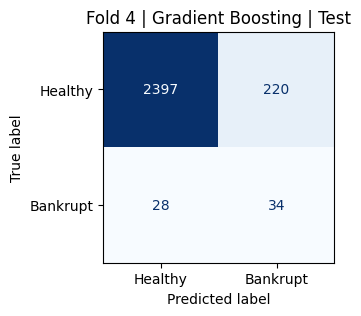

 
Model: Gradient Boosting (Test) | AUC: 0.87
 

[Visualization] Generating Distribution Plot per Fold...
 


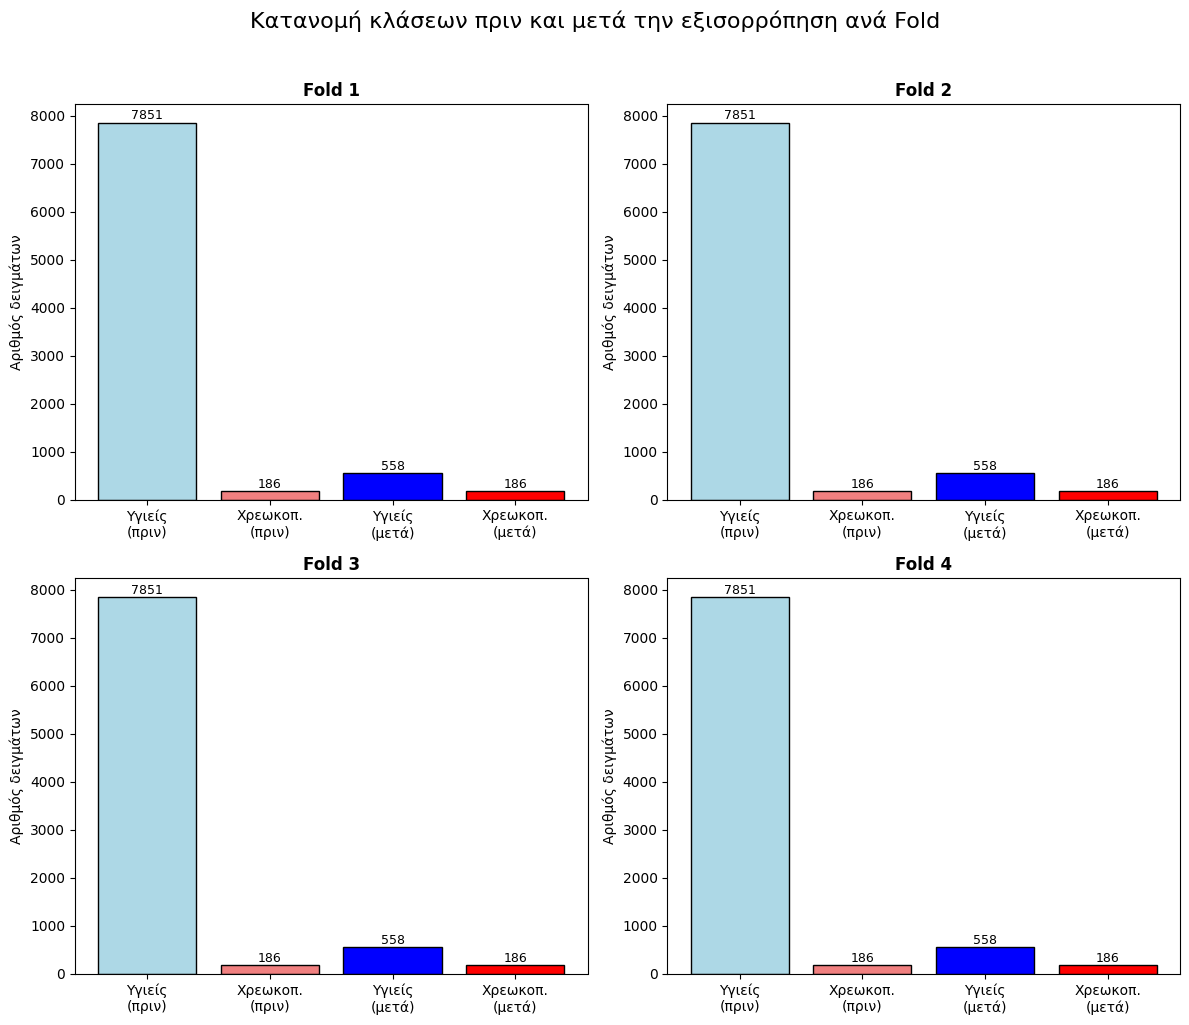

In [7]:
# ----------------------------------------------------------------
# DATA PREPARATION
# ----------------------------------------------------------------
feature_cols = df.columns[:11]
status_col = df.columns[11]

inputData = df[feature_cols].values
outputData = df[status_col].values

# ----------------------------------------------------------------
# INITIALIZE RESULTS DATAFRAME (EXACT COLUMNS ONLY)
# ----------------------------------------------------------------
columns_res = [
    "Classifier Name",
    "Training or test set",
    "Balanced or unbalanced train set",
    "Number of training samples",
    "Number of non-healthy companies in training sample",
    "True positives TP",
    "True negatives TN",
    "False positives FP",
    "False negatives FN",
    "ROC-AUC"
]
results_df = pd.DataFrame(columns=columns_res)

# ----------------------------------------------------------------
# DEFINE MODELS
# ----------------------------------------------------------------
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=2025),
    "Random Forest": RandomForestClassifier(random_state=2025),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=2025),
    "Gradient Boosting": GradientBoostingClassifier(random_state=2025)
}

print("Models initialized.")

# ============================================================================
# TRAINING LOOP
# ============================================================================

n_splits = 4
# Global seed for the KFold split itself
stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=2025)
foldCounter = 1
folds_data = []

print(" Starting Training Loop (4 Folds)...")

for train_index, test_index in stratified_kfold.split(inputData, outputData):

    print("\n" * 2)
    print("="*60)
    print(f"   PROCESSING FOLD {foldCounter}")
    print("="*60)

    # ----------------------------------------------------------------
    # TASK 6: Initial Distribution
    # ----------------------------------------------------------------
    y_train = outputData[train_index]
    y_test = outputData[test_index]

    initial_healthy_train = np.sum(y_train == 1)
    initial_bankrupyscy_train = np.sum(y_train == 2)
    healthy_test = np.sum(y_test == 1)
    bankrupyscy_test = np.sum(y_test == 2)

    print(f"\n--- Fold Set No: {foldCounter} ---")
    print(f"6. Initial Train Set | Υγιείς (1): {initial_healthy_train}, Χρεοκοπημένες (2): {initial_bankrupyscy_train}")
    print(f"6. Test Set          | Υγιείς (1): {healthy_test}, Χρεοκοπημένες (2): {bankrupyscy_test}")

    # ----------------------------------------------------------------
    # TASK 7: Balancing Strategy
    # ----------------------------------------------------------------
    training_index_for_models = train_index
    balancing_ratio_status = "unbalanced"

    if initial_bankrupyscy_train > 0:
        ratio = initial_healthy_train / initial_bankrupyscy_train
        if ratio > 3:
            print("\nATTENTION: Ratio > 3/1 detected. Applying undersampling for balancing")

            healthy_indices = train_index[y_train == 1]
            target_healthy_count = 3 * initial_bankrupyscy_train
            num_to_remove = initial_healthy_train - target_healthy_count

            # --- CRITICAL FIX: Reset Seed INSIDE loop to reproduce exact results ---
            random.seed(2025)
            indices_to_remove = random.sample(list(healthy_indices), int(num_to_remove))

            initial_train_set = set(train_index)
            indices_to_remove_set = set(indices_to_remove)
            balanced_train_set = initial_train_set - indices_to_remove_set

            training_index_for_models = np.array(list(balanced_train_set))
            balancing_ratio_status = "Balanced"

            y_train_balanced = outputData[training_index_for_models]
            print(f"7. New **Balanced** Train Set | Υγιείς (1): {np.sum(y_train_balanced == 1)}, Χρεοκοπημένες (2): {np.sum(y_train_balanced == 2)}")
            print(" ")
        else:
            print("7. Balancing not needed.")
    else:
         print("7. No bankruptcy samples.")

    print("")

    # ----------------------------------------------------------------
    # Prepare Data
    # ----------------------------------------------------------------
    X_train_final = inputData[training_index_for_models]
    y_train_final = outputData[training_index_for_models]
    X_test_final = inputData[test_index]
    y_test_final = outputData[test_index]

    y_train_mapped = np.where(y_train_final == 2, 1, 0)
    y_test_mapped = np.where(y_test_final == 2, 1, 0)

    folds_data.append({
        "Fold": foldCounter,
        "Train (Υγιείς)": initial_healthy_train,
        "Train (Χρεωκοπ.)": initial_bankrupyscy_train,
        "Train Ισορ. (Υγιείς)": np.sum(y_train_final == 1),
        "Train Ισορ. (Χρεωκοπ.)": np.sum(y_train_final == 2)
    })

    # ----------------------------------------------------------------
    # MODEL TRAINING & EVALUATION
    # ----------------------------------------------------------------
    for name, model in models.items():
        model.fit(X_train_final, y_train_mapped)

        eval_sets = {"Train": (X_train_final, y_train_mapped), "Test": (X_test_final, y_test_mapped)}

        for set_name, (X_curr, y_curr) in eval_sets.items():
            y_pred = model.predict(X_curr)
            cm = confusion_matrix(y_curr, y_pred)
            tn, fp, fn, tp = cm.ravel()

            try:
                y_prob = model.predict_proba(X_curr)[:, 1]
                roc = roc_auc_score(y_curr, y_prob)
            except:
                roc = 0.5

            # Plot Confusion Matrix
            plt.figure(figsize=(3, 3))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Bankrupt"])
            disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=False)
            plt.title(f"Fold {foldCounter} | {name} | {set_name}")
            plt.show()

            # Log to DataFrame (EXACT COLUMNS REQUESTED)
            status_label = balancing_ratio_status if set_name == "Train" else "Unbalanced"
            new_row = {
                "Classifier Name": name,
                "Training or test set": set_name,
                "Balanced or unbalanced train set": status_label,
                "Number of training samples": len(X_train_final),
                "Number of non-healthy companies in training sample": np.sum(y_train_final == 2),
                "True positives TP": tp,
                "True negatives TN": tn,
                "False positives FP": fp,
                "False negatives FN": fn,
                "ROC-AUC": round(roc, 2)
            }
            results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

            # Print (Optional: remove if you strictly want no output text, but usually needed for verification)

            print(" ")
            print(f"Model: {name} ({set_name}) | AUC: {roc:.2f}")
            print(" ")


    foldCounter += 1

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n[Visualization] Generating Distribution Plot per Fold...")
print(" ")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Κατανομή κλάσεων πριν και μετά την εξισορρόπηση ανά Fold', fontsize=16, y=1.02)

for idx, ax in enumerate(axes.flatten()):
    if idx >= len(folds_data):
        ax.axis('off')
        continue
    fold_data = folds_data[idx]
    categories = ['Υγιείς\n(πριν)', 'Χρεωκοπ.\n(πριν)', 'Υγιείς\n(μετά)', 'Χρεωκοπ.\n(μετά)']
    values = [fold_data['Train (Υγιείς)'], fold_data['Train (Χρεωκοπ.)'],
              fold_data['Train Ισορ. (Υγιείς)'], fold_data['Train Ισορ. (Χρεωκοπ.)']]
    colors = ['lightblue', 'lightcoral', 'blue', 'red']
    bars = ax.bar(categories, values, color=colors, edgecolor='black')
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()+5, f'{int(value)}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Fold {fold_data["Fold"]}', fontweight='bold')
    ax.set_ylabel('Αριθμός δειγμάτων')

plt.tight_layout()

#Save graph
plt.savefig(
    "katonomi_klaseon_ana_fold.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
# ============================================================================
# TASK 10: Save results to CSV
# ============================================================================
#Save results to CSV
csv_filename = "balancedDataOutcomes.csv"
results_df.to_csv(csv_filename, index=False)
print(f"Results saved to CSV: {csv_filename}")

Results saved to CSV: balancedDataOutcomes.csv
